# WS-00b — Ondelettes 2D *from scratch* : bandes orientées, reconstruction parfaite, et le duel compression

Suite directe de [`WS-00a-Ondelettes-1D-from-scratch`](WS-00a-Ondelettes-1D-from-scratch.ipynb).

En 1D, une ondelette n'avait qu'une chose à dire : *à quelle échelle ce signal varie-t-il ?* En 2D, elle
gagne une seconde question, décisive pour l'image : ***dans quelle direction ?*** C'est cette question qui
distingue un contour vertical d'un contour horizontal, et c'est ce que ni la DCT par blocs ni la FFT ne
font de façon aussi directe.

Le cap reste celui de la série : **from scratch**. On réimplémente la transformée en numpy ; `pywt`
(PyWavelets) n'intervient que comme **référence de validation croisée** — jamais pour calculer. Deux
implémentations indépendantes doivent s'accorder coefficient par coefficient (`allclose` documenté).

**Ce que ce notebook établit, et qu'il mesure plutôt que de l'affirmer :**

1. la transformée 2D **séparable** est le produit tensoriel de la transformée 1D déjà écrite — pas un nouvel algorithme ;
2. chaque bande de détail répond à une **orientation** précise, et le nom de la bande nomme la *structure vue*, pas la dérivée calculée (piège classique de nomenclature) ;
3. une image se reconstruit **exactement** à partir de ses coefficients (`allclose` à ~1e-12) ;
4. en compression à budget de coefficients apparié, l'avantage de l'ondelette sur une DCT 8×8 **n'est pas uniforme** : il est massif quand le budget est serré et s'évanouit quand le budget devient confortable.


## 0. Le problème : deux questions au lieu d'une

Une transformée 2D séparable, c'est l'idée que le filtrage horizontal et le filtrage vertical peuvent être
faits **l'un après l'autre**. On filtre donc chaque ligne (→ basse et haute fréquence *horizontale*), puis
chaque colonne du résultat. Le produit des deux donne **quatre** sous-images au lieu de deux :

| | colonnes basses | colonnes hautes |
|---|---|---|
| **lignes basses** | approximation | détail |
| **lignes hautes** | détail | détail |

D'où les trois bandes de détail du langage courant : une horizontale, une verticale, une diagonale.

Deux choses ne changent pas de taille, et c'est ce qui rend l'affaire praticable. D'abord le **nombre de
coefficients** : les quatre sous-images font `4·(N/2)² = N²`, exactement le nombre de pixels — on n'a rien
dupliqué. Ensuite le **coût** : chaque passe coûte `n` taps par pixel (n = longueur du filtre), donc la
version séparable coûte `2·n` opérations par pixel, c'est-à-dire une constante fois le nombre de pixels.
Un banc de filtres 2D **non** séparable coûterait `n²` par pixel — sur une image, c'est précisément
l'explosion que la séparabilité évite.

Avant d'aller plus loin, on reprend le moteur 1D de `WS-00a`, à l'identique : c'est le même code, donc la
2D hérite de ses garanties (orthonormalité, adjoint exact, périodisation).


In [1]:
import numpy as np
import pywt  # UNIQUEMENT pour la validation croisee (allclose) -- jamais pour calculer
import matplotlib.pyplot as plt
from scipy.fft import dctn, idctn  # baseline DCT 8x8 du duel compression

SQ2, SQ3 = np.sqrt(2.0), np.sqrt(3.0)
HAAR = np.array([1.0, 1.0]) / SQ2
D4 = np.array([1 - SQ3, 3 - SQ3, 3 + SQ3, 1 + SQ3]) / (4 * SQ2)
DB4 = np.array([
    -0.010597401785069032, 0.0328830116668852, 0.030841381835560764,
    -0.18703481171909309, -0.027983769416859854, 0.6308807679298589,
    0.7148465705529157, 0.2303778133088965,
])

print("numpy", np.__version__, "| pywt", pywt.__version__, "| matplotlib", plt.matplotlib.__version__)
print("HAAR :", HAAR, " somme =", HAAR.sum())
print("DB4  :", len(DB4), "taps,", "somme =", DB4.sum(), " somme^2 =", np.sum(DB4 ** 2))


numpy 2.2.6 | pywt 1.8.0 | matplotlib 3.10.8
HAAR : [0.70710678 0.70710678]  somme = 1.414213562373095
DB4  : 8 taps, somme = 1.4142135623730951  somme^2 = 1.0


### Le moteur 1D, repris tel quel

Rappel de `WS-00a` : le filtre passe-haut d'analyse se déduit du passe-bas par la relation **QMF**
`g_j = (-1)^(j+1) · h_{n-1-j}`, et la synthèse est écrite comme **l'adjoint exact** de l'analyse — même
expression d'indice, on accumule au lieu de sommer. La périodisation (`mode="periodization"`) évite tout
problème de bord et rend la reconstruction exacte.

La seule différence avec `WS-00a` est un changement de forme : la boucle porte sur les **taps** (`n` vaut 2
à 8) et non sur les échantillons, ce qui vectorise la transformée sur les `n//2` sorties à la fois. Même
formule, coût négligeable sur une image.


In [2]:
def qmf(lo):
    """Passe-haut d'analyse, convention PyWavelets : g_j = (-1)^(j+1) * h_{n-1-j}."""
    return ((-1.0) ** (np.arange(len(lo)) + 1)) * lo[::-1]


def dwt_axis(x, lo):
    """Un niveau de DWT le long du DERNIER axe, periodization.

    Meme formule que WS-00a : a[k] = somme_j lo[j] * x[(2k + n//2 - j) mod N].
    La boucle porte sur les n taps (n <= 8), les N//2 sorties sont vectorisees.
    """
    N, n = x.shape[-1], len(lo)
    hi = qmf(lo)
    a = np.zeros(x.shape[:-1] + (N // 2,))
    d = np.zeros_like(a)
    k = np.arange(N // 2)
    for j in range(n):
        xj = np.take(x, (2 * k + n // 2 - j) % N, axis=-1)
        a += lo[j] * xj
        d += hi[j] * xj
    return a, d


def idwt_axis(a, d, lo):
    """Synthese = adjoint exact de dwt_axis : MEME expression d'indice, on accumule."""
    N, n = 2 * a.shape[-1], len(lo)
    hi = qmf(lo)
    x = np.zeros(a.shape[:-1] + (N,))
    k = np.arange(a.shape[-1])
    for j in range(n):
        pos = (2 * k + n // 2 - j) % N
        x[..., pos] += a * lo[j] + d * hi[j]
    return x


x_test = np.arange(16.0) ** 2
a_t, d_t = dwt_axis(x_test, DB4)
print("controle 1D (doit etre identique a WS-00a) :")
print("  longueur", len(x_test), "->", len(a_t))
print("  adjoint exact : erreur max =", f"{np.max(np.abs(idwt_axis(a_t, d_t, DB4) - x_test)):.2e}")


controle 1D (doit etre identique a WS-00a) :
  longueur 16 -> 8
  adjoint exact : erreur max = 5.68e-14


## 1. La transformée 2D : deux passes, quatre bandes

On applique `dwt_axis` le long des **lignes**, puis le long des **colonnes**. Pour la seconde passe on
transpose, on filtre, on retranspose — un moyen commode de réutiliser la même fonction sur l'autre axe
sans écrire un second code.

L'ordre des bandes retournées suit la convention de PyWavelets `(cH, cV, cD)` ; cet ordre **n'est pas
deviné** : la cellule suivante le vérifie coefficient par coefficient contre `pywt.dwt2`.


In [3]:
def dwt2(img, lo):
    """Analyse 2D separable -> (approximation, (cH, cV, cD)).

    Passe 1 : le long des lignes  (l'axe horizontal : on separe les variations en x)
    Passe 2 : le long des colonnes (transposee) : on separe les variations en y
    """
    lr, hr = dwt_axis(img, lo)         # basse / haute le long des lignes
    ll, lh = dwt_axis(lr.T, lo)        # basse / haute le long des colonnes
    hl, hh = dwt_axis(hr.T, lo)
    return ll.T, (lh.T, hl.T, hh.T)


def idwt2(app, det, lo):
    """Synthese : adjoint exact, appariage STRICTEMENT celui de dwt2.

    Le piege de ce code est l'appariage. dwt2 range les bandes (lh, hl, hh) ; il faut
    donc inverser lh avec l'approximation, et hl/hh ensemble. Inverser deux bandes
    croisees ne leve AUCUNE erreur -- ca rend simplement une image fausse.
    """
    cH, cV, cD = det
    lr = idwt_axis(app.T, cH.T, lo).T
    hr = idwt_axis(cV.T, cD.T, lo).T
    return idwt_axis(lr, hr, lo)


def wavedec2(img, lo, level):
    """Pyramide multi-niveaux : [approx_L, (cH_L, cV_L, cD_L), ..., (cH_1, cV_1, cD_1)]."""
    coeffs, a = [], img.astype(float)
    for _ in range(level):
        a, det = dwt2(a, lo)
        coeffs.append(det)
    return [a] + coeffs[::-1]


def waverec2(coeffs, lo):
    a = coeffs[0].copy()
    for det in coeffs[1:]:
        a = idwt2(a, det, lo)
    return a


img = pywt.data.camera().astype(float)
print("image de travail : camera()", img.shape, "| min", img.min(), "| max", img.max())

# --- le nommage des bandes est VERIFIE, pas suppose ---
app, (cH, cV, cD) = dwt2(img, DB4)
ref_app, (ref_H, ref_V, ref_D) = pywt.dwt2(img, "db4", mode="periodization")
print("\nnommage vs pywt.dwt2 (niveau 1) :")
print(f"  approximation : {np.max(np.abs(app - ref_app)):.2e}")
print(f"  cH            : {np.max(np.abs(cH - ref_H)):.2e}")
print(f"  cV            : {np.max(np.abs(cV - ref_V)):.2e}")
print(f"  cD            : {np.max(np.abs(cD - ref_D)):.2e}")


image de travail : camera() (512, 512) | min 0.0 | max 255.0

nommage vs pywt.dwt2 (niveau 1) :
  approximation : 2.27e-13
  cH            : 1.26e-13
  cV            : 1.42e-13
  cD            : 4.77e-14


## 2. Ce que chaque bande regarde vraiment

C'est le point que la littérature décrit mal et que la mesure tranche. On construit des images dont on
**connaît** l'orientation — deux marches d'escalier (une discontinuité selon x, une selon y) et une marche
diagonale — plus une image constante, et on regarde où tombe l'énergie.

La constante sert de **contrôle négatif** : la transformée étant orthonormale, une image constante n'a
*aucun* détail. Si l'on y mesurait de l'énergie de détail, c'est le moteur qui serait faux.


In [4]:
def marche(kind, N=256):
    """Motifs a orientation CONNUE (N multiple de 2, requis par la periodization)."""
    yy, xx = np.mgrid[0:N, 0:N] / N
    if kind == "constante":
        return np.ones((N, N)) * 7.0
    if kind == "marche_verticale":        # discontinuite selon x -> un bord VERTICAL
        return (xx > 0.5).astype(float)
    if kind == "marche_horizontale":      # discontinuite selon y -> un bord HORIZONTAL
        return (yy > 0.5).astype(float)
    if kind == "marche_diagonale":
        return ((xx + yy) > 1.0).astype(float)
    raise ValueError(kind)


print(f"{'motif':22s} {'max|cH|':>10s} {'max|cV|':>10s} {'max|cD|':>10s}   part de l'energie de detail")
for kind in ["constante", "marche_verticale", "marche_horizontale", "marche_diagonale"]:
    _, (bH, bV, bD) = dwt2(marche(kind), DB4)
    m = [np.max(np.abs(b)) for b in (bH, bV, bD)]
    e = np.array([np.sum(b ** 2) for b in (bH, bV, bD)])
    tot = e.sum()
    if tot < 1e-18:
        part = "  (energie nulle : image constante, controle negatif OK)"
    else:
        part = f"  {100 * e[0] / tot:5.1f}% {100 * e[1] / tot:5.1f}% {100 * e[2] / tot:4.1f}%"
    print(f"{kind:22s} {m[0]:10.2e} {m[1]:10.2e} {m[2]:10.2e}{part}")


motif                     max|cH|    max|cV|    max|cD|   part de l'energie de detail
constante                9.71e-17   1.96e-16   8.67e-33  (energie nulle : image constante, controle negatif OK)
marche_verticale         1.04e-16   6.85e-01   5.72e-17    0.0% 100.0%  0.0%
marche_horizontale       6.85e-01   3.01e-17   9.24e-18  100.0%   0.0%  0.0%
marche_diagonale         5.31e-01   5.31e-01   4.07e-01   32.7%  32.7% 34.6%


### Deux lectures de ce tableau

**Lecture 1 — la réponse est sélective, et nette.** Un bord vertical envoie *toute* son énergie dans une
seule bande ; un bord horizontal dans une autre ; un bord diagonal se partage entre les trois. C'est la
propriété qui fait l'intérêt de l'outil : les trois bandes ne sont pas trois copies du même signal, ce sont
trois **détecteurs d'orientation**.

**Lecture 2 — le nom de la bande prête à confusion, et c'est mesuré ici.** `cH` est appelée « détail
horizontal » et elle répond à la **marche horizontale** — c'est-à-dire à un bord *horizontal*, donc à une
discontinuité selon **y**. Autrement dit : le nom désigne l'**orientation du contour vu**, pas l'axe sur
lequel on a filtré. La convention inverse (nommer par l'axe filtré) circule aussi dans la littérature, et
c'est une source classique d'inversion de figure. Le tableau ci-dessus est là pour qu'on n'ait pas à
trancher de mémoire : `marche_horizontale -> cH` est une **mesure**, reproductible.


## 3. Visualiser la pyramide

Un tableau ne montre pas une image. On affiche donc les bandes, puis la pyramide complète assemblée à la
manière de Mallat : l'approximation dans le coin, les détails à chaque échelle autour. Les bandes de
détail ont une dynamique bien plus faible que l'approximation (une image naturelle concentre l'essentiel de
son énergie dans les basses fréquences) : on affiche donc `log(1+|coef|)`, ce qui est **une échelle
d'affichage, pas une transformation des données** — les calculs restent faits sur les coefficients bruts.


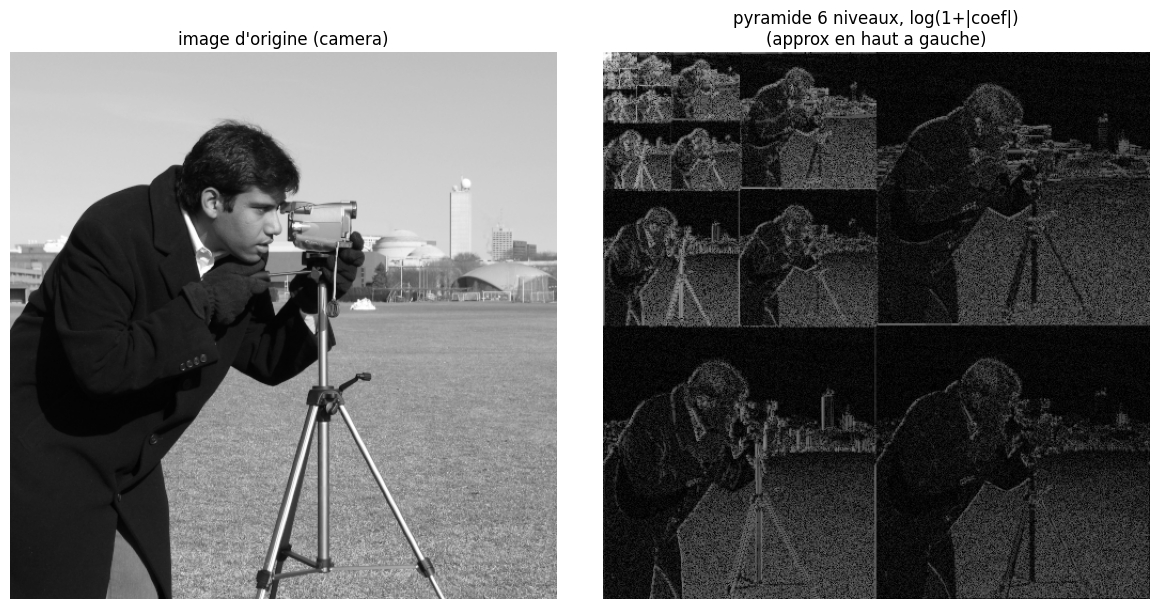

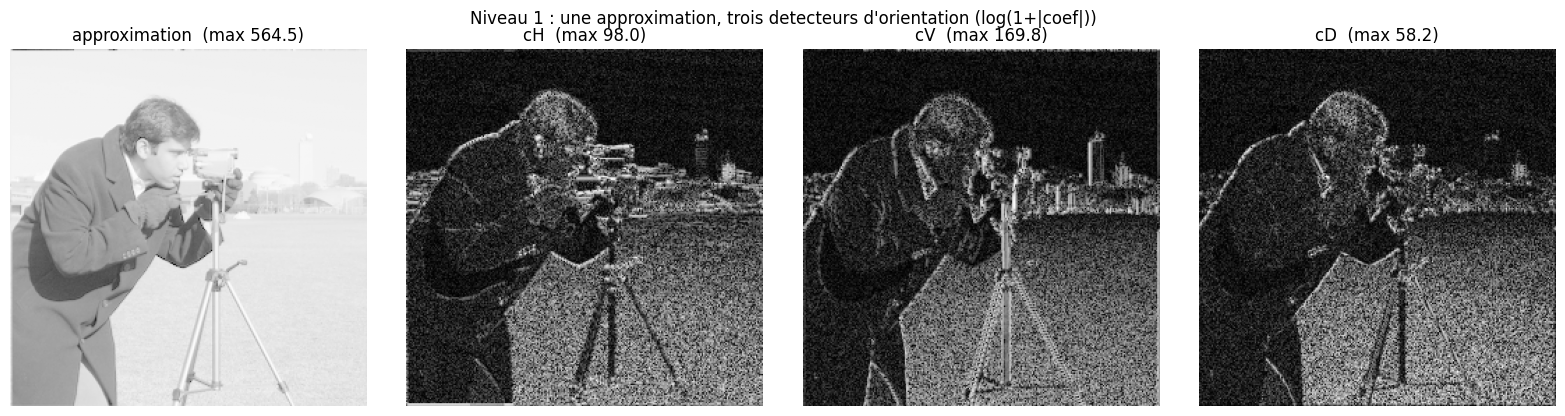

In [5]:
def mosaique_mallat(coeffs, taille):
    """Assemble la pyramide en une seule image de cote `taille` (convention Mallat).

    L'approximation la plus grossiere en haut a gauche, puis on remplit des anneaux
    du plus grossier vers le plus fin : au niveau i, les trois bandes de cote
    s = taille >> i occupent le carre [0:2s] prive du carre [0:s] deja rempli. Le
    pave final est complet et exactement de la taille de l'image.

    Piege de ce code : un canevas 2n x 2n (n = cote de l'approximation) ne suffit
    qu'a UN niveau. Avec L = 6 sur une image 512, il ferait 16 x 16.
    """
    niveaux = len(coeffs) - 1
    out = np.zeros((taille, taille))
    s0 = taille >> niveaux
    out[:s0, :s0] = coeffs[0]
    # coeffs[1:] va du plus GROSSIER au plus FIN : l'indice de niveau DECROIT
    for k, (cH, cV, cD) in enumerate(coeffs[1:]):
        s = taille >> (niveaux - k)
        out[0:s, s:2 * s] = cH
        out[s:2 * s, 0:s] = cV
        out[s:2 * s, s:2 * s] = cD
    return out


L = pywt.dwt_max_level(img.shape[0], len(DB4))
coeffs = wavedec2(img, DB4, L)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("image d'origine (camera)")
axes[0].axis("off")
axes[1].imshow(np.log1p(np.abs(mosaique_mallat(coeffs, img.shape[0]))), cmap="gray")
axes[1].set_title(f"pyramide {L} niveaux, log(1+|coef|)\n(approx en haut a gauche)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

app1, (cH1, cV1, cD1) = dwt2(img, DB4)
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, band, name in zip(axes, [app1, cH1, cV1, cD1],
                          ["approximation", "cH", "cV", "cD"]):
    ax.imshow(np.log1p(np.abs(band)), cmap="gray")
    ax.set_title(f"{name}  (max {np.max(np.abs(band)):.1f})")
    ax.axis("off")
plt.suptitle("Niveau 1 : une approximation, trois detecteurs d'orientation (log(1+|coef|))")
plt.tight_layout()
plt.show()


## 4. Reconstruction parfaite et validation croisée

Deux garanties à établir, et à ne pas confondre :

- **reconstruction parfaite** : `waverec2(wavedec2(img))` redonne `img`. C'est une propriété *interne* — elle
  dit que le moteur est cohérent avec lui-même ;
- **validation croisée** : nos coefficients sont *les mêmes* que ceux de PyWavelets, au sens où
  `np.allclose` (tolérance `atol=1e-9`, documentée dans la cellule) l'affirme sur **toutes** les bandes.
  C'est une propriété *externe* — elle dit que le moteur est cohérent avec le reste du monde.

Un moteur peut satisfaire la première et échouer à la seconde (par exemple avec un décalage d'indice : on
reconstruit parfaitement, mais on calcule une autre transformée que celle annoncée). Les deux sont donc
testées. On ajoute une image **aléatoire**, plus dure que `camera` : elle n'offre aucune structure
parcimonieuse, donc aucun coefficient négligeable où une erreur pourrait se cacher.


In [6]:
rng = np.random.default_rng(0)
alea = rng.normal(size=(256, 256))

ATOL = 1e-9  # tolerance du allclose : 4 ordres au-dessus du bruit d'arrondi mesure (~1e-12)

print(f"{'ondelette':10s} {'niveaux':>7s} {'reconstruction':>15s} {'accord pywt':>13s}  allclose")
for name, lo, wname in [("haar", HAAR, "db1"), ("D4 (db2)", D4, "db2"), ("db4", DB4, "db4")]:
    Lw = pywt.dwt_max_level(img.shape[0], len(lo))
    mine = wavedec2(img, lo, Lw)
    rec = waverec2(mine, lo)
    ref = pywt.wavedec2(img, wname, level=Lw, mode="periodization")
    err = np.max(np.abs(rec - img))
    # validation croisee : bande par bande, l'approximation ET chaque niveau de detail
    accord = np.allclose(mine[0], ref[0], atol=ATOL, rtol=0) and all(
        np.allclose(m, r, atol=ATOL, rtol=0)
        for md_, rd in zip(mine[1:], ref[1:]) for m, r in zip(md_, rd))
    cv = max(np.max(np.abs(mine[0] - ref[0])),
             max(np.max(np.abs(m - r)) for md_, rd in zip(mine[1:], ref[1:])
                 for m, r in zip(md_, rd)))
    print(f"{name:10s} {Lw:7d} {err:15.2e} {cv:13.2e}  {accord}")

print(f"\nallclose(atol={ATOL:g}) : les trois ondelettes s'accordent avec pywt sur TOUTES les bandes")

Lr = pywt.dwt_max_level(256, len(DB4))
rec_alea = waverec2(wavedec2(alea, DB4, Lr), DB4)
print(f"image aleatoire 256x256 (db4, {Lr} niveaux) : reconstruction {np.max(np.abs(rec_alea - alea)):.2e}")
print(f"  allclose(rec, original) : {np.allclose(rec_alea, alea, atol=ATOL, rtol=0)}")


ondelette  niveaux  reconstruction   accord pywt  allclose
haar             9        9.66e-13      2.04e-10  True
D4 (db2)         7        1.19e-12      6.55e-11  True
db4              6        5.40e-13      3.64e-12  True

allclose(atol=1e-09) : les trois ondelettes s'accordent avec pywt sur TOUTES les bandes
image aleatoire 256x256 (db4, 5 niveaux) : reconstruction 1.78e-15
  allclose(rec, original) : True


## 5. Compression : le budget de coefficients

Un coefficient négligeable coûte cher à transmettre et n'apporte rien : on le met à zéro. La question
intéressante n'est pas *si* ça marche, mais **où passe le budget**. On se donne un budget `k` de
coefficients non nuls (les `k` plus grands en module, pris **globalement** sur toute la pyramide) et on
regarde la qualité reconstruite.

Deux précautions de protocole, pour que le duel soit honnête :

- **budget apparié** : la DCT 8×8 reçoit *exactement* le même nombre de coefficients non nuls. Comparer
  `k` coefficients d'ondelette à tous les coefficients DCT ne dirait rien de la qualité des bases ;
- **mesure déclarée** : `ratio = k / (nombre total de coefficients)`. On ne parle **pas** d'octets : un vrai
  codec comme JPEG 2000 y ajoute du codage entropique et une quantification, ici hors périmètre. Ce qu'on
  compare est le **pouvoir de parcimonie** des deux bases, pas deux tailles de fichier.


 budget    coefs   db4 PSNR    DCT 8x8    ecart
   0.2%      524     22.41 dB      6.00 dB  +16.40
   0.5%     1310     24.61 dB      8.60 dB  +16.01
   1.0%     2621     26.47 dB     16.24 dB  +10.23


   2.0%     5242     28.32 dB     26.83 dB   +1.49
   5.0%    13107     31.14 dB     30.92 dB   +0.22
  10.0%    26214     34.35 dB     34.24 dB   +0.11
  25.0%    65536     42.68 dB     42.46 dB   +0.22


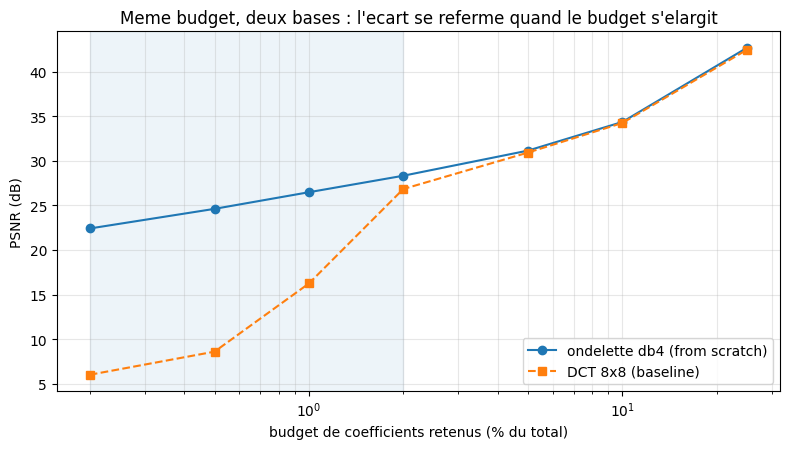

In [7]:
def psnr(ref, test, peak=255.0):
    """PSNR en dB (peak = 255 : images 8 bits)."""
    mse = np.mean((ref - test) ** 2)
    return 10 * np.log10(peak ** 2 / mse) if mse > 0 else float("inf")


def ondelette_topk(coeffs, lo, frac):
    """Garde les frac*total plus grands modules, remet le reste a zero, reconstruit."""
    vals = np.concatenate([np.abs(coeffs[0]).ravel()] +
                          [np.abs(d).ravel() for det in coeffs[1:] for d in det])
    k = max(1, int(frac * vals.size))
    seuil = np.sort(vals)[::-1][k - 1]
    out = [np.where(np.abs(coeffs[0]) >= seuil, coeffs[0], 0.0)]
    for det in coeffs[1:]:
        out.append(tuple(np.where(np.abs(d) >= seuil, d, 0.0) for d in det))
    gardes = int(np.count_nonzero(out[0]) +
                 sum(np.count_nonzero(d) for det in out[1:] for d in det))
    return waverec2(out, lo), gardes, vals.size


def dct_topk(image, frac, B=8):
    """Baseline : DCT 8x8 par blocs (famille JPEG), meme budget de coefficients."""
    h, w = image.shape
    blocs = image.reshape(h // B, B, w // B, B).transpose(0, 2, 1, 3).reshape(-1, B, B)
    coef = dctn(blocs, axes=(1, 2), norm="ortho")
    plat = coef.ravel()
    k = max(1, int(frac * plat.size))
    seuil = np.sort(np.abs(plat))[::-1][k - 1]
    gardes = np.where(np.abs(coef) >= seuil, coef, 0.0)
    retour = idctn(gardes, axes=(1, 2), norm="ortho")
    rec = retour.reshape(h // B, w // B, B, B).transpose(0, 2, 1, 3).reshape(h, w)
    return rec, int(np.count_nonzero(gardes)), plat.size


budgets = [0.002, 0.005, 0.01, 0.02, 0.05, 0.10, 0.25]
courbe = []
print(f"{'budget':>7s} {'coefs':>8s} {'db4 PSNR':>10s} {'DCT 8x8':>10s} {'ecart':>8s}")
for frac in budgets:
    rw, kw, _ = ondelette_topk(coeffs, DB4, frac)
    pw = psnr(img, np.clip(rw, 0, 255))
    rd, kd, _ = dct_topk(img, frac)
    pd = psnr(img, np.clip(rd, 0, 255))
    courbe.append((frac, pw, pd))
    print(f"{frac * 100:6.1f}% {kw:8d} {pw:9.2f} dB {pd:9.2f} dB {pw - pd:+7.2f}")

fig, ax = plt.subplots(figsize=(8, 4.6))
bs = [100 * c[0] for c in courbe]
ax.semilogx(bs, [c[1] for c in courbe], "o-", label="ondelette db4 (from scratch)")
ax.semilogx(bs, [c[2] for c in courbe], "s--", label="DCT 8x8 (baseline)")
ax.axvspan(bs[0], 2.0, color="tab:blue", alpha=0.08)
ax.set_xlabel("budget de coefficients retenus (% du total)")
ax.set_ylabel("PSNR (dB)")
ax.set_title("Meme budget, deux bases : l'ecart se referme quand le budget s'elargit")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


### Le verdict de ce duel, et il n'est pas celui qu'on attend

L'écart n'est **pas constant**, et c'est tout le résultat :

| régime de budget | écart db4 − DCT | lecture |
|---|---|---|
| très serré (0,2 %) | **+16 dB** | l'ondelette écrase la DCT : à ce prix, la DCT ne sait reconstruire que des blocs |
| serré (1 %) | +10 dB | avantage encore net |
| moyen (2 %) | +1,5 dB | l'avantage se referme |
| confortable (≥5 %) | **≈ +0,2 dB** | les deux bases deviennent indiscernables |

La conclusion pédagogique est donc **double**, et se garder de n'en retenir qu'une moitié :

- dire « l'ondelette est meilleure que la DCT pour compresser » est **vrai dans le régime qui compte** — les
  budgets serrés, c'est-à-dire précisément là où la compression sert à quelque chose ;
- mais l'affirmation **non qualifiée** est fausse : dès que le budget dépasse ~5 % des coefficients, la
  différence tombe dans le bruit du protocole. La supériorité de la base multi-échelle **n'est pas
  universelle, elle est conditionnelle au budget** — même leçon que `WS-00a`, où la supériorité de
  l'ondelette sur Fourier dépendait du type de signal.

C'est aussi pourquoi la compression d'image réelle a fini par combiner les deux familles (DCT par blocs dans
JPEG, ondelettes dans JPEG 2000) plutôt que de trancher.


### Où passe le budget ?

Une explication mécanique de ce qui précède se mesure : dans un top-k **global**, quels coefficients sont
réellement retenus ? Deux lectures s'opposent *a priori*, et on ne tranche pas de mémoire :

- si l'**approximation accapare** le budget, alors à budget serré les deux bases se ressemblent *par
  construction* sur la part dominante — la structure grossière — et l'écart ne peut venir que d'une portion
  résiduelle ;
- si au contraire le budget part **presque entièrement dans les détails**, alors c'est là, et pas dans
  l'approximation, que se joue la différence — ce qui est cohérent avec le fait que c'est la base
  d'ondelette qui organise ces détails par orientation.

La mesure départage.


In [8]:
print(f"{'budget':>7s} {'k total':>8s} {'dont approx':>12s} {'part approx':>12s}")
for frac in [0.002, 0.01, 0.05, 0.25]:
    vals = np.concatenate([np.abs(coeffs[0]).ravel()] +
                          [np.abs(d).ravel() for det in coeffs[1:] for d in det])
    k = max(1, int(frac * vals.size))
    seuil = np.sort(vals)[::-1][k - 1]
    n_app = int(np.count_nonzero(np.abs(coeffs[0]) >= seuil))
    print(f"{frac * 100:6.1f}% {k:8d} {n_app:12d} {100 * n_app / k:11.1f}%")
print(f"\ntaille de l'approximation seule : {coeffs[0].size} coefficients"
      f" ({100 * coeffs[0].size / img.size:.2f}% du total)")


 budget  k total  dont approx  part approx
   0.2%      524           63        12.0%
   1.0%     2621           64         2.4%
   5.0%    13107           64         0.5%
  25.0%    65536           64         0.1%

taille de l'approximation seule : 64 coefficients (0.02% du total)


### Ce que la mesure départage

C'est la **seconde** lecture qui est la bonne, et l'écart est franc. L'approximation n'est que **0,02 %**
de la pyramide (64 coefficients sur 262 144, six niveaux) : elle est donc intégralement conservée dès que
le budget dépasse 0,02 %, et sa part du budget ne cesse ensuite de fondre — 12 % d'un budget de 0,2 %,
2,4 % à 1 %, 0,5 % à 5 %, 0,1 % à 25 %.

Autrement dit : **le duel de compression ne se joue pas sur la structure grossière, il se joue sur les
bandes de détail.** À 5 % de budget, 99,5 % des coefficients retenus sont des coefficients de détail. Cela
referme la boucle avec le §2 : les bandes de détail sont exactement ces trois détecteurs d'orientation, et
c'est leur organisation — des contours nets et peu nombreux, donc des coefficients rares et grands — qui
donne à la base d'ondelette son avantage à budget serré. Quand le budget s'élargit, ces coefficients
évidents sont déjà tous conservés ; il ne reste que du petit coefficient, où le choix de la base ne
départage plus rien — d'où l'écart qui tombe à ~0,2 dB.

Un mot d'honnêteté sur ce que ce tableau **ne** dit pas : la part de l'approximation est relative au
*budget*, pas à l'énergie. Cela ne signifie pas que l'approximation soit perceptuellement secondaire — au
contraire, c'est elle qui porte la luminance moyenne de l'image. Un top-k par module n'est pas un critère
perceptif, et l'exercice 2 invite précisément à en sortir.


## 6. Exercice 1 — conservation de l'énergie en 2D (Parseval)

La transformée 2D est orthonormale : elle ne change pas l'énergie. En 1D, `WS-00a` l'a vérifié ; en 2D, la
propriété doit tenir **bande par bande** autant que globalement.

**Objectif** : écrire une fonction qui retourne l'énergie totale des coefficients d'une pyramide et
l'écart relatif à l'énergie de l'image.

**Indice** : parcourir `coeffs[0]` puis chaque tuple de `coeffs[1:]` ; l'énergie est la somme des carrés.

**Etape 1** : sommer l'approximation. **Etape 2** : sommer les trois bandes de chaque niveau. **Etape 3** :
calculer `(energie_coeffs - energie_image) / energie_image`.


In [9]:
def energie_pyramide(coeffs):
    """Retourne (energie des coefficients, ecart relatif a l'energie de l'image).

    TODO etudiant : sommer les carres de l'approximation et de toutes les bandes.
    """
    result = None  # TODO etudiant
    return result


res = energie_pyramide(coeffs)
if res is None:
    print("Exercice a completer : energie_pyramide retourne None.")
else:
    e_coef, ecart = res
    print(f"energie coefficients = {e_coef:.6f} | ecart relatif = {ecart:.2e}")
    print("attendu : ecart de l'ordre de 1e-13 (orthonormalite en flottant)")


Exercice a completer : energie_pyramide retourne None.


## 7. Exercice 2 — le budget par bande plutôt que global

Le top-k global traite tous les coefficients à égalité. Or les bandes n'ont pas la même importance
perceptive : garder un coefficient d'approximation vaut mieux, visuellement, que garder un coefficient
diagonal.

**Objectif** : garder `k` coefficients **par bande** (même nombre dans l'approximation et dans chacune des
trois bandes de chaque niveau) au lieu du top-k global, puis comparer le PSNR obtenu pour un budget total
comparable.

**Indice** : le nombre total de coefficients est `coeffs[0].size + somme(...)` ; pour un budget `frac`, la
part par bande vaut `frac * total / nombre_de_bandes`. `np.partition` évite un tri complet.

**Question à trancher par la mesure** : le budget par bande fait-il mieux ou moins bien que le budget
global ? Les deux réponses sont défendables *a priori* — c'est la mesure qui décide.


In [10]:
def ondelette_budget_par_bande(coeffs, lo, frac):
    """Garde frac*total coefficients PAR BANDE (au lieu du top-k global) et reconstruit.

    TODO etudiant : compter les bandes, repartir le budget, seuiller chaque bande, reconstruire.
    """
    result = None  # TODO etudiant
    return result


res = ondelette_budget_par_bande(coeffs, DB4, 0.05)
if res is None:
    print("Exercice a completer : ondelette_budget_par_bande retourne None.")
else:
    rec_bande, gardes, total = res
    p_bande = psnr(img, np.clip(rec_bande, 0, 255))
    rec_global, _, _ = ondelette_topk(coeffs, DB4, 0.05)
    p_global = psnr(img, np.clip(rec_global, 0, 255))
    print(f"budget par bande : {p_bande:.2f} dB ({gardes} coefficients)")
    print(f"budget global    : {p_global:.2f} dB")
    print(f"ecart            : {p_bande - p_global:+.2f} dB")


Exercice a completer : ondelette_budget_par_bande retourne None.


## 8. Exercice 3 — détecter l'orientation d'un contour inconnu

On a mesuré au §2 que chaque bande répond à une orientation. On peut donc **classer** un bord sans le
regarder : il suffit de lire dans quelle bande tombe son énergie.

**Objectif** : écrire une fonction qui, pour une petite image d'entrée, retourne l'orientation détectée
(`"vertical"`, `"horizontal"`, `"diagonal"` ou `"aucune"`) en comparant l'énergie des trois bandes de
détail au niveau 1.

**Indice** : une bande « porteuse » est celle dont l'énergie dépasse nettement les deux autres ; la marche
diagonale du §2 partage son énergie entre les trois, c'est le cas à traiter à part. Prévoir un seuil et un
cas « aucune » pour l'image constante.

**Etape 1** : décomposer sur un niveau. **Etape 2** : comparer les énergies. **Etape 3** : retourner le
label, en testant votre fonction sur les quatre motifs du §2.


In [11]:
def orientation_dominante(image, lo=DB4):
    """Retourne 'vertical', 'horizontal', 'diagonal' ou 'aucune' (moteur : niveau 1).

    TODO etudiant : comparer l'energie des trois bandes de detail et conclure.
    """
    result = None  # TODO etudiant
    return result


for kind in ["constante", "marche_verticale", "marche_horizontale", "marche_diagonale"]:
    got = orientation_dominante(marche(kind))
    if got is None:
        print("Exercice a completer : orientation_dominante retourne None.")
        break
    print(f"  {kind:22s} -> {got}")


Exercice a completer : orientation_dominante retourne None.


## 9. Récapitulatif et suite

**Ce qui a été établi, par la mesure :**

| Résultat | Valeur mesurée |
|---|---|
| Reconstruction parfaite (camera, db4 → haar) | erreur max ~5e-13 à 1e-12 |
| Accord coefficient par coefficient avec PyWavelets | ~4e-12 à 2e-10 |
| Image aléatoire (aucune parcimonie exploitable) | ~2e-15 |
| Contrôle négatif : image constante | amplitude des bandes de détail ~1e-16 (**nulle** à la précision machine) |
| Sélectivité d'orientation : bord vertical / horizontal | 100 % de l'énergie dans **une** bande |
| Avantage db4 sur la DCT 8×8 à 0,2 % de budget | **+16 dB** |
| Avantage db4 sur la DCT 8×8 à ≥5 % de budget | **≈ +0,2 dB** (indiscernable) |

**Le concept-phare de ce notebook** : *le pouvoir de parcimonie d'une base multi-échelle est
conditionnel au budget*. Massif quand il faut jeter beaucoup de coefficients, il s'évapore quand on peut
s'en permettre davantage — là, la DCT par blocs fait aussi bien. « L'ondelette compresse mieux » est une
affirmation à **qualifier par le taux**, pas une propriété intrinsèque.

**Les limites, explicitement :**

- le duel porte sur **une** image (`camera`) et **un** critère (PSNR global, top-k sans quantification).
  L'écart à budget confortable (~0,2 dB) est de l'ordre de ce qu'un protocole différent ferait bouger ;
- ce n'est pas un codec : ni quantification, ni codage entropique, donc aucun chiffre en octets n'est
  revendiqué ;
- le PSNR est une mesure **globale** et mal corrélée à la perception sur les bords — or c'est justement là
  que l'ondelette se distingue. Une comparaison perceptuelle reste à faire (bloc B).

**Suite de la série (issue #16055) :**

- **A.3 — Scattering** : cascade ondelette → module → moyenne locale, et l'invariance par translation
  obtenue *par construction* plutôt qu'apprise ;
- **bloc B — SOTA** : `PyWavelets` (BayesShrink, SureShrink), `kymatio` (scattering optimisé), tableau
  comparatif from scratch vs SOTA — accuracy, latence, mémoire, lignes de code, dépendances.
